In [1]:
from platform import python_version
print(python_version())

3.12.12


### Scanpy

Scanpy is a scalable toolkit for analyzing single-cell gene expression data built jointly with anndata. It includes preprocessing, visualization, clustering, trajectory inference and differential expression testing. The Python-based implementation efficiently deals with datasets of more than one million cells. For datasets too large to fit into memory, many scanpy functions are now compatible with dask (warning: experimental).

https://scanpy.readthedocs.io/en/stable/index.html

---

## 📑 Table of contents

### Instalation

Released: Aug 27, 2026  
scanpy 1.12.4  
Requires Python >=3.12  


### Github

https://github.com/scverse/scanpy


### GPU

https://rapids-singlecell.readthedocs.io/en/latest/




### Other tutorials and studies


Current Best Practices in Single-Cell RNA-Seq Analysis: A Tutorial [Luecken & Theis, 2019](https://doi.org/10.15252/msb.20188746) by Malte Lücken and Fabian Theis introduces best practices for scRNA-seq analysis. Its key contribution lies in not only reviewing potential analysis steps but also recommending best practices based on independent benchmarks. When specific best-practice guidelines are unavailable, the authors provide general recommendations for analysis approaches. The fundamental idea of focusing on independent benchmarks inspired our work substantially. The paper is complemented by [an example analysis of mouse intestinal epithelium regions](https://github.com/theislab/single-cell-tutorial/) from Haber et al. [Haber et al., 2017](https://doi.org/10.1038/nature24489).


### Scripts for "Current best-practices in single-cell RNA-seq: a tutorial"

https://github.com/theislab/single-cell-tutorial/

![workflow](../figures/singlecell_workflow.png)

In [12]:
import os, sys, yaml
from pathlib import Path
from dotenv import load_dotenv

import numpy as np
import pandas as pd
pd.set_option('display.width', 100)
pd.set_option('max_colwidth', 80)
pd.set_option("display.precision", 3)

import seaborn as sns
sns.set_context("notebook", font_scale=1.4)

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
%matplotlib inline

ROOT0 = Path("/home/flavio/uv/single_cell_scanpy_studies/")
ROOT_SRC = ROOT0 / "src"

sys.path.insert(0, str(ROOT_SRC))


if str(ROOT_SRC) not in sys.path:
    sys.path.append(str(ROOT_SRC))

print("ROOT0:", ROOT0)
print("ROOT_SRC added:", ROOT_SRC)

from libs.Basic import create_dir
from libs.config_lib import Config

from IPython.display import display, HTML
# display(HTML("<style>.container { width:100% !important; }</style>"))
display(HTML("<style>:root { --jp-notebook-max-width: 100% !important; }</style>"))

with open('../params.yml', 'r') as file:
    dic_yml = yaml.safe_load(file)

# print(dic_yml)

ROOT0: /home/flavio/uv/single_cell_scanpy_studies
ROOT_SRC added: /home/flavio/uv/single_cell_scanpy_studies/src


In [13]:
email = os.getenv('email')

i_project=0

project_list = dic_yml['project_list']
n = len(project_list)
project = project_list[i_project]

s_project_list = dic_yml['s_project_list']
s_project = s_project_list[i_project]
assert n==len(project_list), f"Error project_list: there are {n} projects"

ROOT0_DATA = create_dir(ROOT0, "data")
root_colab = create_dir(ROOT0_DATA, "colab")

CONTEXT_DISESE = 'xxxx'
context_disease = CONTEXT_DISESE

gene_protein = dic_yml['gene_protein']
s_omics = dic_yml['s_omics']

has_age = dic_yml['has_age']
has_gender = dic_yml['has_gender']

exp_normalization = dic_yml['exp_normalization']
normalization = 'quantile_norm' if exp_normalization == True else 'not_normalized'

LFC_cut_inf = dic_yml['LFC_cut_inf']
s_pathw_enrichm_method = dic_yml['s_pathw_enrichm_method']
ptw_min_num_of_degs_cut = dic_yml['ptw_min_num_of_degs_cut']

tolerance_pPMI = dic_yml['tolerance_pPMI']
type_sat_ptw_index = dic_yml['type_sat_ptw_index']
saturation_lfc_param = dic_yml['saturation_lfc_param']

pval_pathway_cutoff = dic_yml['pval_pathway_cutoff']
fdr_pathway_cutoff = dic_yml['fdr_pathway_cutoff']
num_of_genes_cutoff = dic_yml['num_of_genes_cutoff']
enr_db_list = dic_yml['enr_db_list']

case_list = dic_yml['case_list']
dic_case_list = dic_yml['dic_case_list']

std_filename      = dic_yml['std_filename']
std_filename_list = dic_yml['std_filename_list']

min_lfc_modulation = dic_yml['min_lfc_modulation']
num_of_genes_list  = dic_yml['num_of_genes_list']
pPMI_normalized  = dic_yml['pPMI_normalized']

#--- max len for formatting purposes
s_len_case  = dic_yml['s_len_case']

n_sentences = dic_yml['n_sentences']
run_list = dic_yml['run_list']
chosen_model_list = dic_yml['chosen_model_list']
i_dfp_list = dic_yml['i_dfp_list']
chosen_model_sampling = dic_yml['chosen_model_sampling']

fdr_ptw_cutoff_list = np.arange(0.05, 0.80, 0.05)
lfc_list = np.round(np.arange(1.0, -0.01, -.025), 3)
fdr_list = np.arange(0.05, 0.76, .01)


### Scanpy Introduction

https://scanpy.readthedocs.io/en/stable/tutorials/basics/clustering.html#

In [14]:
# Core scverse libraries
from __future__ import annotations

import anndata as ad

# Pooch is a Python library that can manage data by downloading files from a server (only when needed) and storing them locally in a data cache 
import pooch
import scanpy as sc

In [7]:
sc.set_figure_params(dpi=50, facecolor="white")

### Getting data

The data used in this basic preprocessing and clustering tutorial was collected from bone marrow mononuclear cells of healthy human donors and was part of openproblem’s NeurIPS 2021 benchmarking dataset [Luecken et al., 2021]. The samples used in this tutorial were measured using the 10X Multiome Gene Expression and Chromatin Accessability kit.

We are reading in the count matrix into an AnnData object, which holds many slots for annotations and different representations of the data. See Getting started with anndata for a tutorial.

anndata: https://anndata.scverse.org/en/stable/tutorials/notebooks/getting-started.html

In [17]:
root_h5 = create_dir(ROOT0_DATA, "h5")
os.listdir(root_h5)

['s1d1_filtered_feature_bc_matrix.h5', 's1d3_filtered_feature_bc_matrix.h5']

In [18]:
EXAMPLE_DATA = pooch.create(
    path=pooch.os_cache(str(root_h5)),
    base_url="doi:10.6084/m9.figshare.22716739.v1/",
)
EXAMPLE_DATA.load_registry_from_doi()

### UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.

Two different warnings, both harmless in your code and both expected:

1. "Variable names are not unique" from readwrite.py

This fires inside sc.read_10x_h5, before your code ever runs. 10x's features.tsv uses gene symbols as names, and a handful of Ensembl IDs map to the same symbol (e.g. TBCE, LINC01238, some HLA-* loci), so the raw file has duplicate var_names. Scanpy copies the AnnData during reading, and AnnData's copy checks uniqueness and warns. Your very next line, sample_adata.var_names_make_unique(), is exactly the fix — it appends -1, -2 to the duplicates. The warning just happens one line before you get the chance.

You see it twice because you read two files.

2. "Observation names are not unique" from ad.concat

Both samples come from the same 10x chemistry, so they share the same barcode whitelist. A barcode like AAACCCAAGGTTCCGC-1 can legitimately appear in both s1d1 and s1d3 (different cells, same barcode). When ad.concat stacks them, those collide. Again your next line, adata.obs_names_make_unique(), resolves it.

The cleaner fix is to tell concat to prefix barcodes with the sample key, which produces meaningful names (s1d1-AAACCC...) instead of -1/-2 suffixes, and removes the warning entirely:

In [23]:
import warnings

samples = {
    "s1d1": "s1d1_filtered_feature_bc_matrix.h5",
    "s1d3": "s1d3_filtered_feature_bc_matrix.h5",
}
adatas = {}

for sample_id, filename in samples.items():
    path = EXAMPLE_DATA.fetch(filename)

    with warnings.catch_warnings():
        warnings.simplefilter("ignore", UserWarning)
        sample_adata = sc.read_10x_h5(path)
        
    sample_adata.var_names_make_unique()
    adatas[sample_id] = sample_adata

# keep sample first
adata = ad.concat(adatas, label="sample", index_unique="_")
adata.obs_names_make_unique()
print(adata.obs["sample"].value_counts())

sample
s1d1    8785
s1d3    8340
Name: count, dtype: int64


In [24]:
adata

AnnData object with n_obs × n_vars = 17125 × 36601
    obs: 'sample'
    layers: None (.X)

### Quality Control

The scanpy function calculate_qc_metrics() calculates common quality control (QC) metrics, which are largely based on calculateQCMetrics from scater [McCarthy et al., 2017]. One can pass specific gene population to calculate_qc_metrics() in order to calculate proportions of counts for these populations. Mitochondrial, ribosomal and hemoglobin genes are defined by distinct prefixes as listed below.

In [26]:
len(adata.var_names), adata.var_names

(36601,
 Index(['MIR1302-2HG', 'FAM138A', 'OR4F5', 'AL627309.1', 'AL627309.3', 'AL627309.2', 'AL627309.5',
        'AL627309.4', 'AP006222.2', 'AL732372.1',
        ...
        'AC133551.1', 'AC136612.1', 'AC136616.1', 'AC136616.3', 'AC136616.2', 'AC141272.1',
        'AC023491.2', 'AC007325.1', 'AC007325.4', 'AC007325.2'],
       dtype='object', length=36601))

In [27]:
# mitochondrial genes, "MT-" for human, "Mt-" for mouse
adata.var["mt"] = adata.var_names.str.startswith("MT-")
# ribosomal genes
# RPS: Ribosomal Protein Small subunit (Proteína Ribossómica da Subunidade Pequena)
# RPL: Ribosomal Protein Large subunit (Proteína Ribossómica da Subunidade Grande)
adata.var["ribo"] = adata.var_names.str.startswith(("RPS", "RPL"))
# hemoglobin genes
adata.var["hb"] = adata.var_names.str.contains("^HB[^(P)]")

### calculate_qc_metrics

Calculate quality control metrics.

Calculates a number of qc metrics for an AnnData object, see section Returns for specifics. Largely based on calculateQCMetrics from scater [McCarthy et al., 2017]. Currently is most efficient on a sparse CSR or dense matrix.

https://scanpy.readthedocs.io/en/stable/generated/scanpy.pp.calculate_qc_metrics.html#scanpy.pp.calculate_qc_metrics

qc_vars: Keys for boolean columns of .var which identify variables you could want to control for (e.g. “ERCC” or “mito”).

In [28]:
sc.pp.calculate_qc_metrics(adata, qc_vars=["mt", "ribo", "hb"], inplace=True, log1p=True)

### One can now inspect violin plots of some of the computed QC metrics:

- the number of genes expressed in the count matrix
- the total counts per cell
- the percentage of counts in mitochondrial genes


### These are the three standard per-cell QC metrics that sc.pp.calculate_qc_metrics writes into adata.obs. 

Each is computed per cell (one value per row/barcode):

- total_counts — the sum of all UMI counts across every gene in that cell. 
  - This is the library size / sequencing depth for the cell. 
  - Also called total counts or nUMI. 
  - A cell with total_counts = 12000 had 12,000 transcripts captured.

- n_genes_by_counts — the number of distinct genes with at least one count in that cell (i.e., how many genes are non-zero). 
  - This measures transcriptional complexity. A cell can have high total counts but few genes if a handful of genes dominate.

What each fraction tells you

- pct_counts_mt - mitochondrial fraction. 
  - High values flag dying or lysing cells: the membrane ruptured, cytoplasmic mRNA leaked out, and the mito transcripts protected inside mitochondria stayed behind, so their proportion spikes. Classic apoptosis/stress signature.

- pct_counts_ribo - ribosomal-protein fraction. 
  - Ribosomal genes are among the most highly expressed transcripts in any cell, so this is often 20–50% and that alone isn't a problem. 
  - It's used more as a covariate and a cell-type signal than a hard filter: 
    - proliferating and metabolically active cells (relevant in tumors) run high, 
    - and abnormally low ribo can also mark low-quality cells.
  - Some pipelines regress it out or exclude ribo genes from HVG selection.

- pct_counts_hb — hemoglobin fraction. 
  - This flags red-blood-cell contamination / ambient hemoglobin. 
  - In a solid-tumor dissociation like PDAC there's almost always blood contamination, 
  - so a high-hb population is usually erythrocytes or ambient-RNA-contaminated cells you want to drop rather than a real cell type of interest.

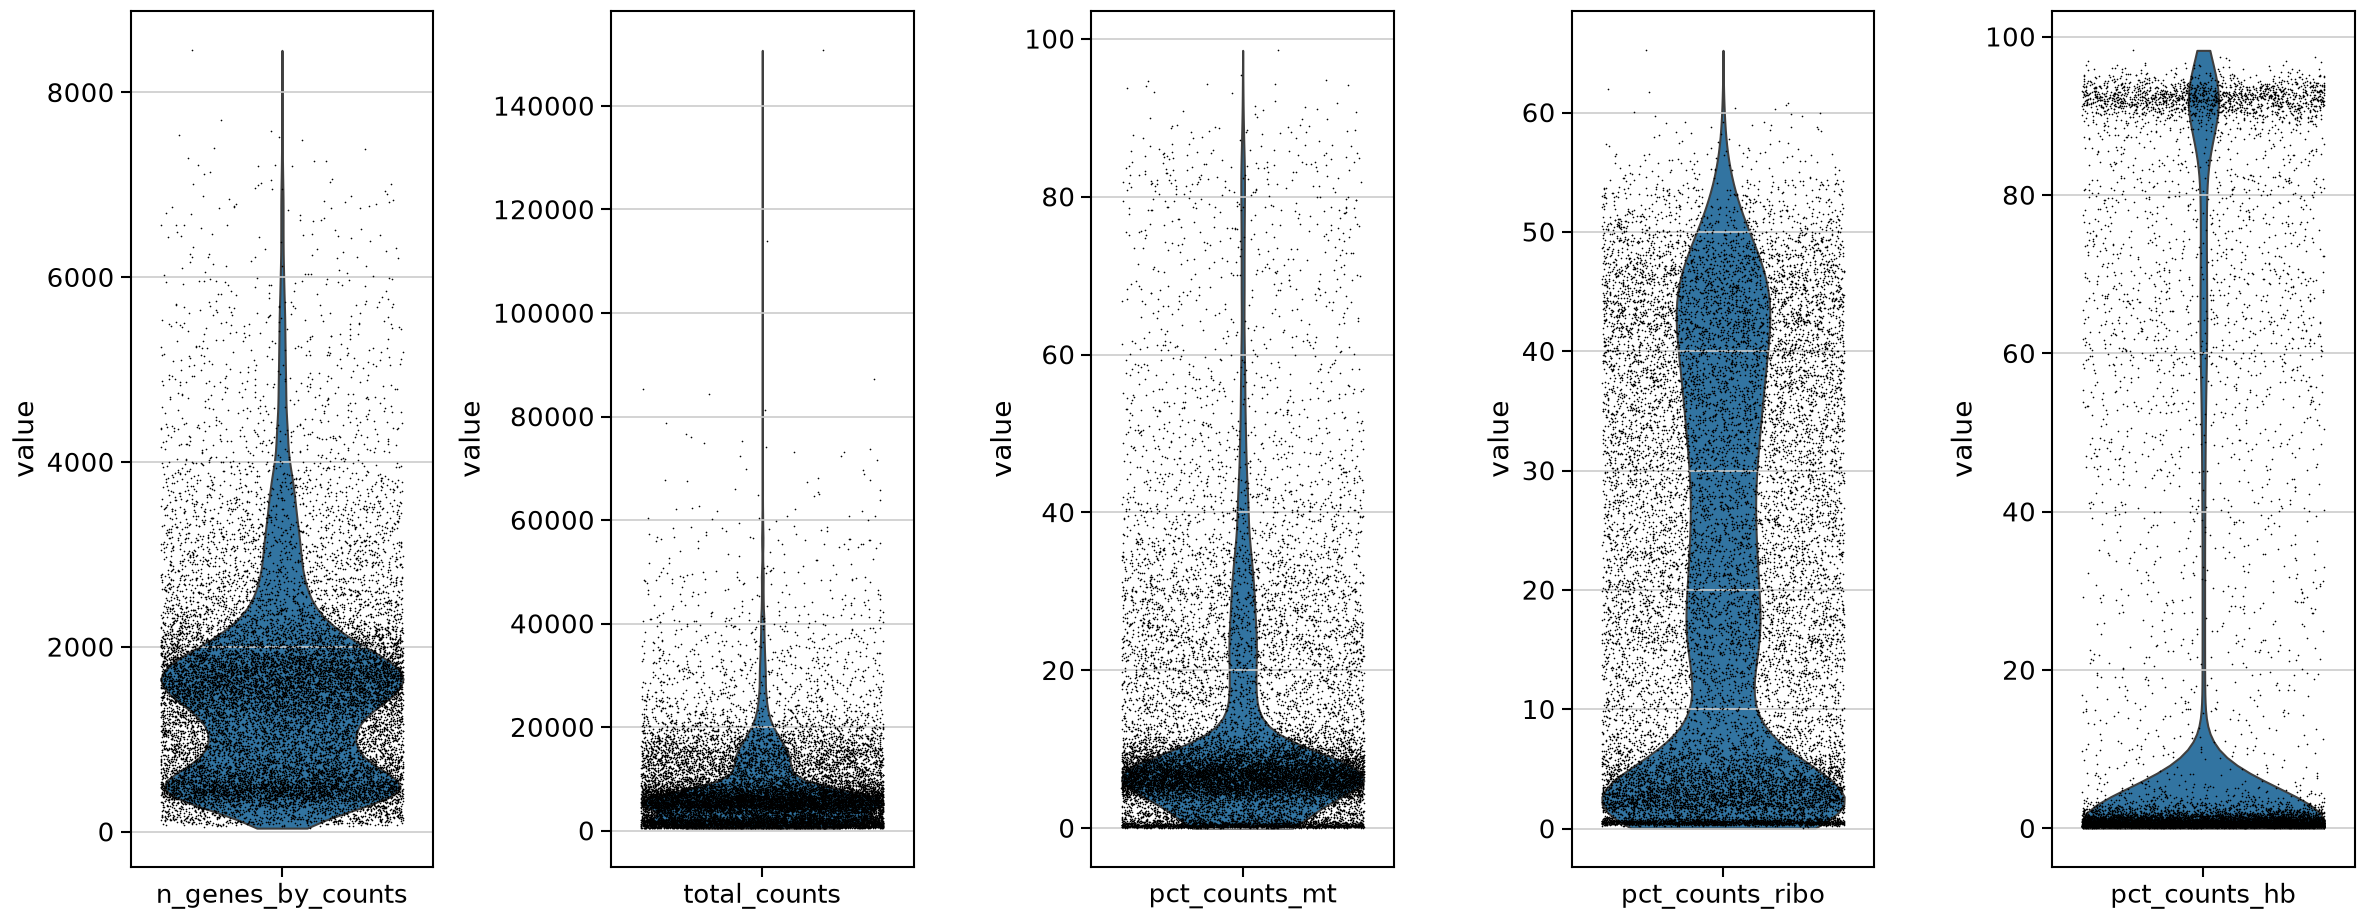

In [37]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 5, figsize=(20, 8))

for ax, key in zip(axes, ["n_genes_by_counts", "total_counts", "pct_counts_mt", "pct_counts_ribo", "pct_counts_hb"]):
    sc.pl.violin(adata, key, jitter=0.4, ax=ax, show=False)
plt.tight_layout()



###  it is useful to consider QC metrics jointly by inspecting a scatter plot colored by pct_counts_mt.

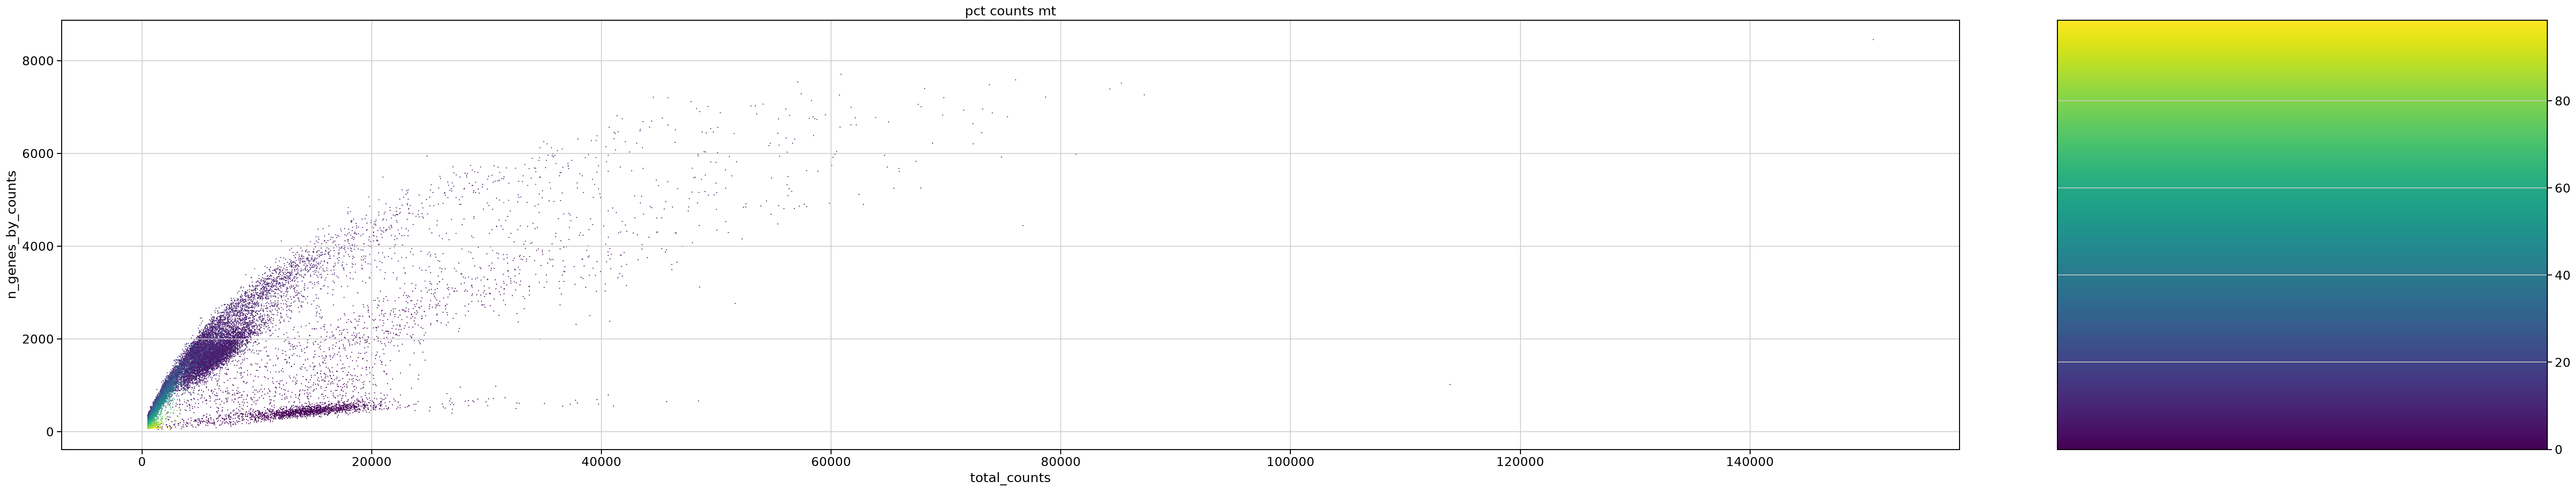

In [43]:
sc.pl.scatter(adata, "total_counts", "n_genes_by_counts", color="pct_counts_mt", show=False);

### remove cells that have too many ...

Based on the QC metric plots, one could now remove cells that have too many mitochondrial genes expressed or too many total counts by setting manual or automatic thresholds. However, sometimes what appears to be poor QC metrics can be driven by real biology so we suggest starting with a very permissive filtering strategy and revisiting it at a later point. We therefore now only filter cells with less than 100 genes expressed and genes that are detected in less than 3 cells.

### batches are groups (cases x controls, e.g.)
Additionally, it is important to note that for datasets with multiple batches, quality control should be performed for each sample individually as quality control thresholds can vary substantially between batches.



In [44]:
sc.pp.filter_cells(adata, min_genes=100)
sc.pp.filter_genes(adata, min_cells=3)

### Doublet detection

As a next step, we run a doublet detection algorithm. Identifying doublets is crucial as they can lead to misclassifications or distortions in downstream analysis steps. Scanpy contains the doublet detection method Scrublet [Wolock et al., 2019]. Scrublet predicts cell doublets using a nearest-neighbor classifier of observed transcriptomes and simulated doublets. scanpy.pp.scrublet() adds doublet_score and predicted_doublet to .obs. One can now either filter directly on predicted_doublet or use the doublet_score later during clustering to filter clusters with high doublet scores.

scanpy.pp.scrublet()

Predict cell doublets using a nearest-neighbor classifier of observed transcriptomes and simulated doublets. Works best if the input is a raw (unnormalized) counts matrix from a single sample or a collection of similar samples from the same experiment. This function is a wrapper around functions that pre-process using Scanpy and directly call functions of Scrublet(). You may also undertake your own preprocessing, simulate doublets with scrublet_simulate_doublets(), and run the core scrublet function scrublet() with adata_sim set.

https://scanpy.readthedocs.io/en/stable/api/generated/scanpy.pp.scrublet.html#scanpy.pp.scrublet

In [49]:
sc.pp.scrublet(adata, batch_key="sample")

We can remove doublets by either filtering out the cells called as doublets, or waiting until we’ve done a clustering pass and filtering out any clusters with high doublet scores.

See also

Alternative methods for doublet detection within the scverse ecosystem are [DoubletDetection](https://github.com/JonathanShor/DoubletDetection) and [SOLO](https://docs.scvi-tools.org/en/stable/user_guide/models/solo.html). You can read more about these in the [Doublet Detection chapter](https://www.sc-best-practices.org/preprocessing_visualization/quality_control.html#doublet-detection) of Single Cell Best Practices.

Single-cell best practices by Anna Schaar, Seo H. Kim, Lukas Heumos, and Luke Zappia

Quality Control - https://www.sc-best-practices.org/preprocessing-visualization/quality-control/

### Normalization

The next preprocessing step is normalization. A common approach is count depth scaling with subsequent log plus one (log1p) transformation. Count depth scaling normalizes the data to a “size factor” such as the median count depth in the dataset, ten thousand (CP10k) or one million (CPM, counts per million). The size factor for count depth scaling can be controlled via target_sum in pp.normalize_total. We are applying median count depth normalization with log1p transformation (AKA log1PF).

In [50]:
# Saving count data

adata.layers["counts"] = adata.X.copy()

### Normalizing to median total counts

In [51]:
sc.pp.normalize_total(adata)
# Logarithmize the data
sc.pp.log1p(adata)

### Feature selection

As a next step, we want to reduce the dimensionality of the dataset and only include the most informative genes. This step is commonly known as feature selection. The scanpy function pp.highly_variable_genes annotates highly variable genes by reproducing the implementations of Seurat [Satija et al., 2015](https://scanpy.readthedocs.io/en/stable/references.html#id54), Cell Ranger [Zheng et al., 2017](https://scanpy.readthedocs.io/en/stable/references.html#id78), and Seurat v3 [Stuart et al., 2019](https://scanpy.readthedocs.io/en/stable/references.html#id62) depending on the chosen flavor.